In [85]:
%reload_ext autoreload
%autoreload 2

import os
import sys
import pickle
from tqdm import tqdm

import numpy as np
np.float = np.float64

import healpy as hp
import jax.numpy as jnp

sys.path.append("/n/home07/yitians/fermi/NPTFit/NPTFit")
sys.path.append("/n/home07/yitians/fermi/NPTFit")
from NPTFit import npll

sys.path.append("../nptfit")
from nptfit_func import *

sys.path.append("..")
from utils import create_mask as cm
from models.templates import NFWTemplate, LorimerDiskTemplate
from models.psf import KingPSF
from utils.utils import find_max_point

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file('../notebooks/matplotlibrc')

In [2]:
#psf_name = 'king'
psf_name = 'delta'
if psf_name == 'king':
    kp = KingPSF()
    f_ary, df_rho_div_f_ary = psf_corr(psf_r_func = kp.psf_fermi_r, num_f_bins=30)
elif psf_name == 'delta':
    sigma = np.deg2rad(0.1) / 3
    psf_r_func = lambda r: np.exp(-0.5 * (r / sigma) ** 2) / (2 * np.pi * sigma ** 2)
    f_ary, df_rho_div_f_ary = psf_corr(psf_r_func = psf_r_func, num_f_bins=30)

df = f_ary[1] - f_ary[0]
plot = False
if plot:
    plt.plot(f_ary, df_rho_div_f_ary/df*f_ary**2)
    plt.fill_between(f_ary, df_rho_div_f_ary/df*f_ary**2, 0., alpha=0.5)
    plt.ylabel(r'$f\cdot\rho(f)$')
    plt.xlabel(r'$f$');

In [3]:
fct_max = 1000

def log_factorial(m):
    return np.sum(np.log(np.arange(1., m + 1., dtype=np.float128)))

log_factorial_ary = np.vectorize(log_factorial)(np.arange(fct_max))

In [6]:
def return_xs(theta, npt_compressed, data):

    a, s0 = theta
    k_max = int(np.max(data) + 1)
    npix_roi = len(npt_compressed)

    x_m_ary = np.zeros((npix_roi, k_max + 1))
    x_m_sum = np.zeros(npix_roi)

    for p in range(npix_roi):
        m_ary = np.arange(k_max + 1)
        x_m_ary[p] = a * npt_compressed[p] * s0**m_ary * np.exp(-s0) / np.exp(log_factorial_ary[:k_max + 1])
        x_m_sum[p] = a * npt_compressed[p] - x_m_ary[p, 0]

    return x_m_ary, x_m_sum

In [7]:
DTYPE = np.float64

def log_like(pt_sum_compressed, theta, npt_compressed, data):

    k_max = np.max(data) + 1
    npixROI = len(pt_sum_compressed)
    x_m_ary = np.zeros((npixROI, k_max + 1), dtype=DTYPE)
    x_m_sum = np.zeros(npixROI, dtype=DTYPE)

    i = 0
    x_m_ary_out = np.zeros((npixROI, k_max + 1), dtype=DTYPE)
    x_m_sum_out = np.zeros(npixROI, dtype=DTYPE)

    for i in range(len(theta)):
        x_m_ary_out, x_m_sum_out = return_xs(np.array(theta[i]), npt_compressed[i], data)
        x_m_ary += np.asarray(x_m_ary_out)
        x_m_sum += np.asarray(x_m_sum_out)

    return log_like_internal(pt_sum_compressed, data, x_m_ary, x_m_sum, k_max, npixROI)

def log_like_internal(pt_sum_compressed, data, x_m_ary, x_m_sum, k_max, npixROI):

    pk = np.zeros((k_max+1), dtype=DTYPE)

    # Loop over pixels
    ll = 0.
    for p in range(npixROI):
        # Define p_0 (pk[0]) and p_1 (pk[1])
        # Then the remaining p_k are determined recursively up to the value of 
        # k = data in that pixel
        f0_ary = -(pt_sum_compressed[p] + x_m_sum[p])
        f1_ary = (pt_sum_compressed[p] + x_m_ary[p,1])
        pk[0] = np.exp(f0_ary)
        pk[1] = pk[0] * f1_ary

        for k in range(2, data[p]+1):
            pk[k] = 0.
            for n in range(0, k-1):
                pk[k] += (k-n)/float(k)*x_m_ary[p,k-n]*pk[n]
            pk[k] += f1_ary*pk[k-1]/float(k)

        # Need prob > 0 to define a LL
        # If a very bad fit can get prob = 0, if so then penalise to avoid this region
        if pk[data[p]] > 0:
            ll += np.log(pk[data[p]])
        else:
            ll += -10.1**10.

    return ll

## 1 pixel

In [27]:
pt_sum_compressed = np.array([0.])
npt_compressed = np.array([[1.]])
data_s = [
    np.array([3], dtype=np.int64),
    np.array([7], dtype=np.int64),
    np.array([12], dtype=np.int64),
]

Sps_arr = np.linspace(0.1, 15, 100)

ll_ss = []
for data in data_s:
    ll_s = []
    for Sps in Sps_arr:
        s0 = 5
        a = Sps / s0
        theta = [[a, s0]]
        ll = log_like(pt_sum_compressed, theta, npt_compressed, data)
        ll_s.append(ll)
    ll_ss.append(ll_s)

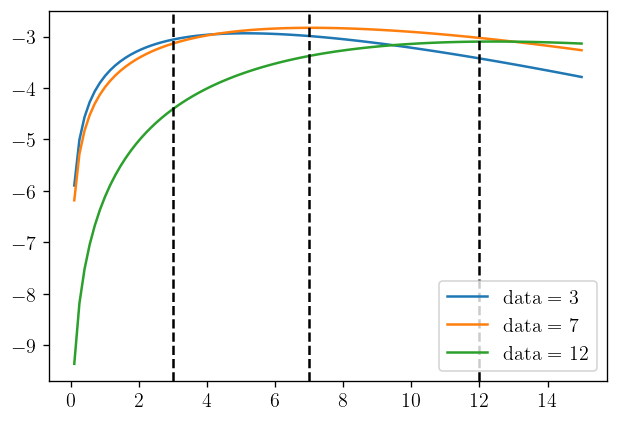

In [28]:
plt.plot(Sps_arr, ll_ss[0], label='data = 3')
plt.plot(Sps_arr, ll_ss[1], label='data = 7')
plt.plot(Sps_arr, ll_ss[2], label='data = 12')
plt.axvline(3, color='k', ls='--')
plt.axvline(7, color='k', ls='--')
plt.axvline(12, color='k', ls='--')
plt.legend()

## N pixels

In [70]:
# simulate 1 template
n_pix = 100
n_sim = 100
truth_dict = dict(
    Sps = 15,
)
npt_temp = np.random.uniform(0, 1, size=n_pix)
npt_temp /= np.mean(npt_temp)
data_s = []
s0 = 5

for i in tqdm(range(n_sim)):
    n_src = np.random.poisson(npt_temp*truth_dict['Sps']/s0)
    data_s.append(np.random.poisson(s0*n_src))
data_s = np.array(data_s)

100%|██████████| 100/100 [00:00<00:00, 23231.99it/s]


In [87]:
# multiple templates
n_pix = 100
vd_base = dict(
    Sps_t0 = None,
    Sps_t1 = None,
    s0_t0 = 5,
    s0_t1 = 3,
)
regen_temps = False
if regen_temps:
    for i in range(5):
        z = np.random.uniform(size=n_pix)
        z /= np.mean(z)
        np.save(f'toytemp_{i}.npy', z)

## truth

In [119]:
include_temps = [0, 1]

save_dir = 'toysim_t' + ''.join([str(i) for i in include_temps])
os.makedirs(save_dir, exist_ok=True)
vd = vd_base.copy()
vd['Sps_t0'] = 10.
vd['Sps_t1'] = 15.
pickle.dump(vd, open(f"{save_dir}/truth.p", 'wb'))

## simulate

In [109]:
n_sim = 100

temps = [np.load(f'toytemp_{i}.npy') for i in include_temps]

data_s = []
for i_sim in tqdm(range(n_sim)):
    data = np.zeros(n_pix)
    for i in include_temps:
        key = f't{i}'
        Sps = vd['Sps_'+key]
        s0 = vd['s0_'+key]
        n_src = np.random.poisson(temps[i] * Sps / s0)
        data += np.random.poisson(s0*n_src)
    data_s.append(data)
data_s = np.array(data_s, dtype=np.int64)
np.save(f"{save_dir}/data_s.npy", data_s)

100%|██████████| 100/100 [00:00<00:00, 11486.84it/s]


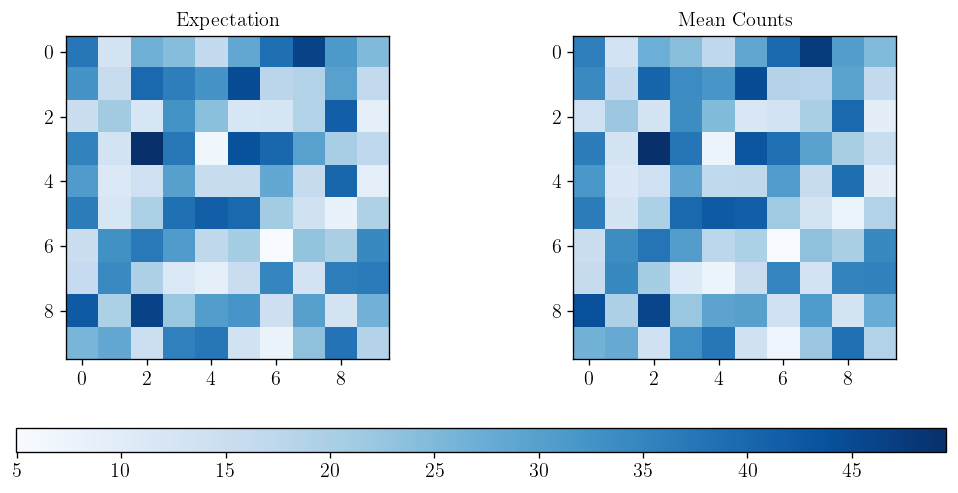

In [110]:
mean_counts = np.zeros_like(data_s[0], dtype=np.float64)
for i in range(n_sim):
    mean_counts += data_s[i]
mean_counts /= float(n_sim)

expectation = np.zeros_like(data_s[0], dtype=np.float64)
for i in range(5):
    if f'Sps_t{i}' in vd:
        expectation += temps[i] * vd[f'Sps_t{i}']

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
vmin, vmax = np.min(expectation), np.max(expectation)
axs[0].imshow(expectation.reshape(10, 10), vmin=vmin, vmax=vmax, cmap='Blues')
im = axs[1].imshow(mean_counts.reshape(10, 10), vmin=vmin, vmax=vmax, cmap='Blues')
fig.colorbar(im, ax=axs, orientation='horizontal', aspect=40)
axs[0].set_title('Expectation')
axs[1].set_title('Mean Counts');

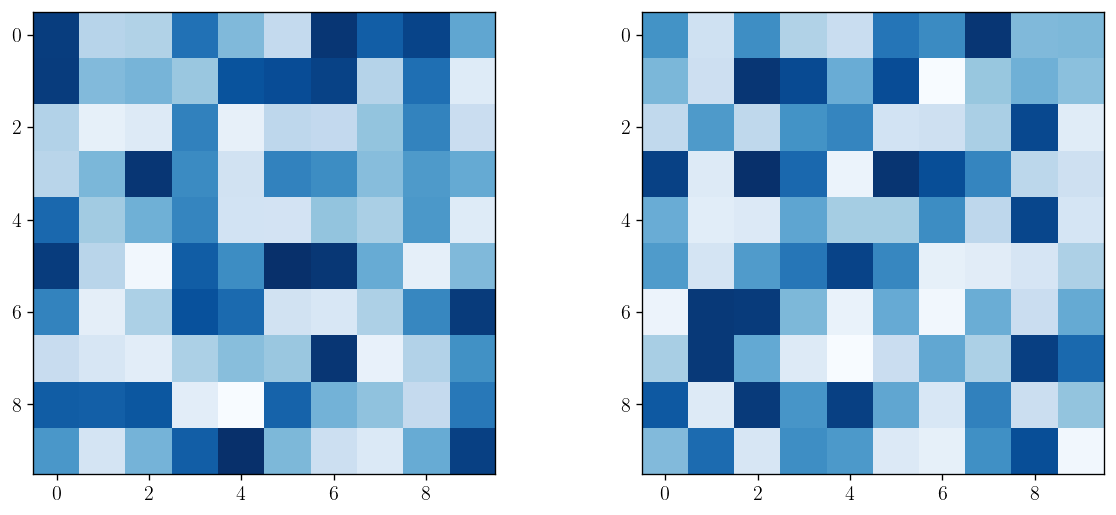

In [114]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(temps[0].reshape(10, 10), cmap='Blues')
axs[1].imshow(temps[1].reshape(10, 10), cmap='Blues')

mean =  25.0212


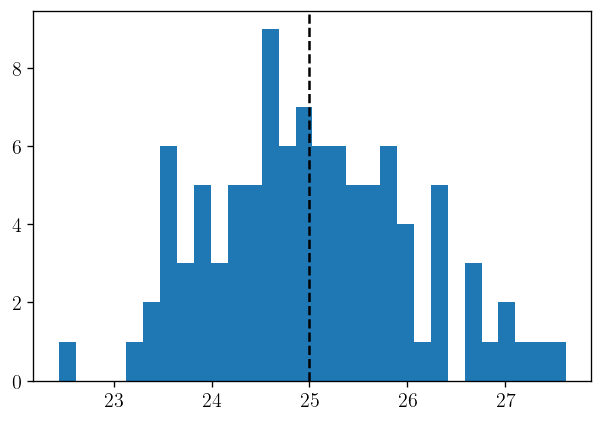

In [115]:
plt.hist(np.mean(data_s, axis=1), bins=30)
plt.axvline(np.mean(expectation), color='k', ls='--')
print('mean = ', np.mean(data_s))

## scan

In [122]:
pt_sum_compressed = np.zeros_like(temps[0])
npt_compressed = [temps[i] for i in range(5) if i in include_temps]

Sps_key = 't0'

Sps_arr = np.linspace(0.5*vd['Sps_'+Sps_key], 1.5*vd['Sps_'+Sps_key], 100)

ll_ss = []
counts_arr = []
for data in tqdm(data_s):
    ll_s = []
    counts_arr.append(np.sum(data))
    for Sps_target in Sps_arr:
        theta = []
        for i in include_temps:
            key = f't{i}'
            Sps = vd['Sps_'+key]
            if key == Sps_key:
                Sps = Sps_target
            s0 = vd['s0_'+key]
            a = Sps / s0
            theta.append([a, s0])
        ll = log_like(pt_sum_compressed, theta, npt_compressed, data)
        ll_s.append(ll)
    ll_ss.append(ll_s)

100%|██████████| 100/100 [03:52<00:00,  2.32s/it]


## plot

In [120]:
vd

{'Sps_t0': 10.0, 'Sps_t1': 15.0, 's0_t0': 5, 's0_t1': 3}

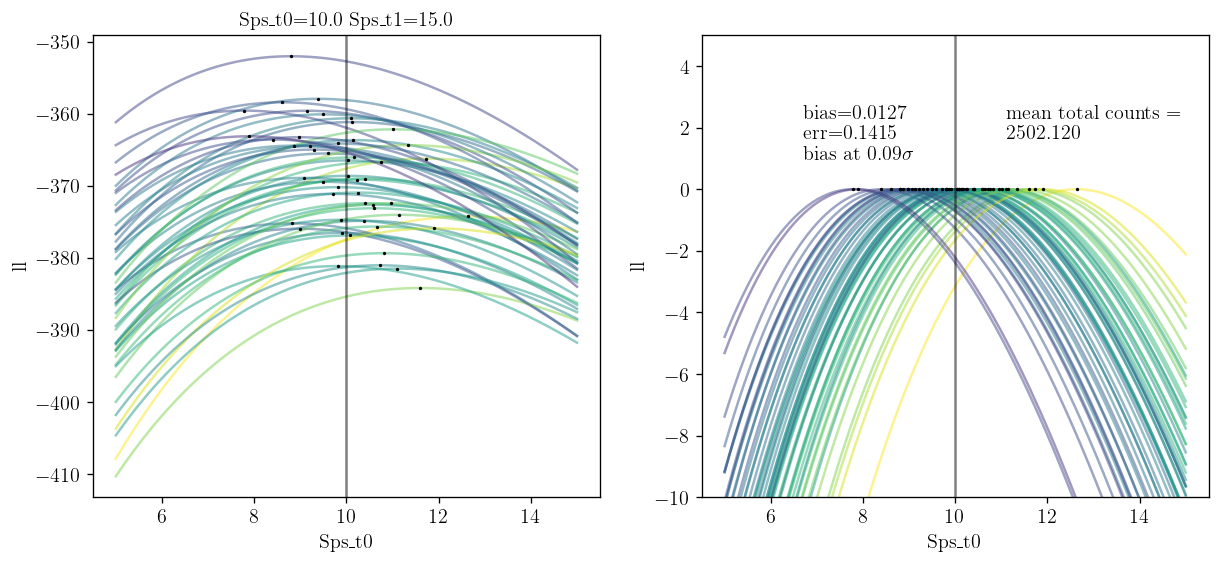

In [123]:
ll_ss = np.array(ll_ss).astype(np.float64)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

max_x_s = []
max_y_s = []
Sps_s = Sps_arr

for i in range(50):
    ax = axs[0]
    color_x = (counts_arr[i] - np.min(counts_arr)) / (np.max(counts_arr) - np.min(counts_arr))
    color = cms['viridis'](color_x)
    rll = ll_ss[i]
    ax.plot(Sps_s, rll, color=color, alpha=0.5)
    max_x, max_y = find_max_point(Sps_s, rll)
    ax.plot(max_x, max_y, 'k.', ms=2, zorder=10)
    max_x_s.append(max_x)
    max_y_s.append(max_y)

    ax = axs[1]
    rll = ll_ss[i] - np.max(ll_ss[i])
    ax.plot(Sps_s, rll, color=color, alpha=0.5)
    max_x, max_y = find_max_point(Sps_s, rll)
    ax.plot(max_x, max_y, 'k.', ms=2, zorder=10)

title_str = " ".join([f"Sps_{k}={vd['Sps_'+k]}" for k in ['t0', 't1']])

ax = axs[0]
ax.axvline(vd['Sps_'+Sps_key], color='k', ls='-', alpha=0.5)
ax.set(title=title_str, xlabel="Sps_"+Sps_key, ylabel='ll')

ax = axs[1]
ax.axvline(vd['Sps_'+Sps_key], color='k', ls='-', alpha=0.5)
ax.set(ylim=(-10, 5))
ax.set(xlabel="Sps_"+Sps_key, ylabel='ll')

bias = (np.mean(max_x_s) - vd['Sps_'+Sps_key])
err = np.std(max_x_s) / np.sqrt(len(max_x_s))
bias_sigma = bias/err

ax.text(0.2, 0.85, f"bias={bias:.4f}\nerr={err:.4f}\nbias at {bias_sigma:.2f}"+r"$\sigma$", transform=ax.transAxes, va='top')
ax.text(0.6, 0.85, f"mean total counts = \n{np.mean(counts_arr):.3f}", transform=ax.transAxes, va='top');